<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="350" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


-   Extract information from a given web site 
-   Write the scraped data into a csv file.


## Extract information from the given web site

You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [2]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

/Users/olesiamironenko/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Download the webpage at the url


In [3]:
data  = requests.get(url).text

Create a soup object


In [4]:
soup = BeautifulSoup(data,"html5lib")

Scrape the `Language name`, `Created By` `annual average salary`and `Learning Difficulty`.


In [14]:
table = soup.find("table")

headers = []

header_row = table.find("tr")

for cell in header_row.find_all("td"):
    headers.append(cell.get_text(strip=True))

print(headers)

language_idx = headers.index("Language")
created_idx = headers.index("Created By")
salary_idx = headers.index("Average Annual Salary")
learning_idx = headers.index("Learning Difficulty")

print(language_idx, created_idx, salary_idx, learning_idx)

rows = []

for row in table.find_all("tr")[1:]:  # skip header row
    cols = row.find_all("td")

    if len(cols) > max(language_idx, salary_idx):
        rows.append({
            "Language": cols[language_idx].get_text(strip=True),
            "Created By": cols[created_idx].get_text(strip=True),
            "Average Annual Salary": cols[salary_idx].get_text(strip=True),
            "Learning Difficulty": cols[learning_idx].get_text(strip=True)
        })



['No.', 'Language', 'Created By', 'Average Annual Salary', 'Learning Difficulty']
1 2 3 4


Create a _dataframe_ for scrapped data


In [15]:
df = pd.DataFrame(rows)
df

,Language,Created By,Average Annual Salary,Learning Difficulty
0,Python,Guido van Rossum,"$114,383",Easy
1,Java,James Gosling,"$101,013",Easy
2,R,"Robert Gentleman, Ross Ihaka","$92,037",Hard
3,Javascript,Netscape,"$110,981",Easy
4,Swift,Apple,"$130,801",Easy
5,C++,Bjarne Stroustrup,"$113,865",Hard
6,C#,Microsoft,"$88,726",Hard
7,PHP,Rasmus Lerdorf,"$84,727",Easy
8,SQL,"Donald D. Chamberlin, Raymond F. Boyce.","$84,793",Easy
9,Go,"Robert Griesemer, Ken Thompson, Rob Pike.","$94,082",Difficult


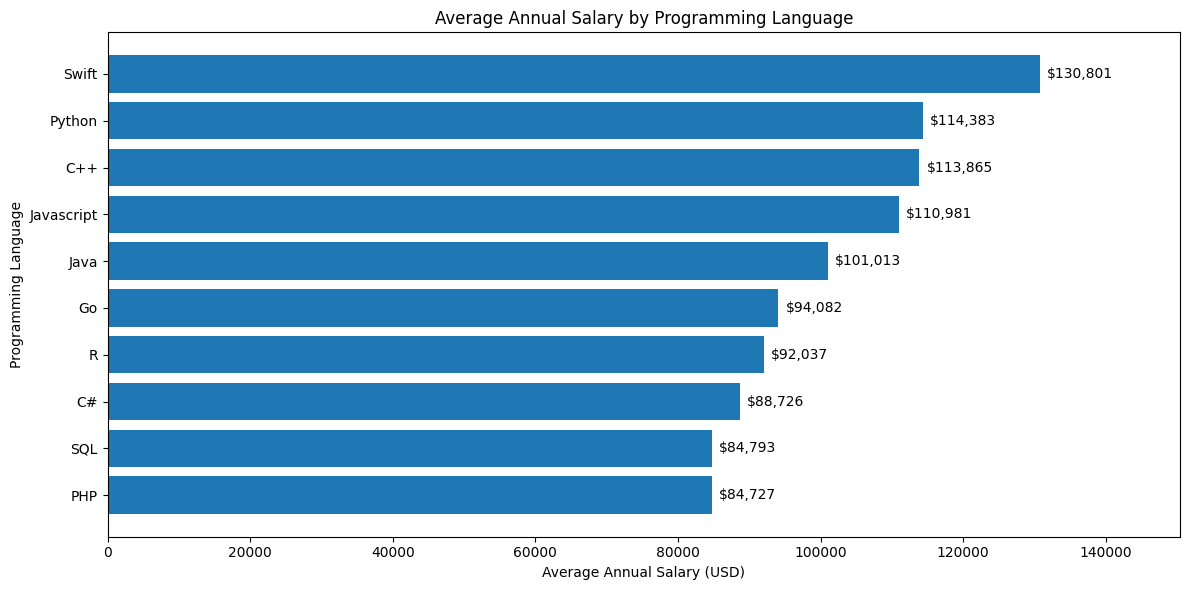

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove $ and commas, then convert to numeric
df["Average Annual Salary"] = (
    df["Average Annual Salary"]
    .replace(r"[\$,]", "", regex=True)
    .astype(int)
)

# Sort by salary (descending)
df = df.sort_values(by="Average Annual Salary", ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(df["Language"], df["Average Annual Salary"])

plt.xlim(0, df["Average Annual Salary"].max() * 1.15)

# Highest salary at the top
plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():,.0f}',
        va='center'
    )

plt.title("Average Annual Salary by Programming Language")
plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("Programming Language")

plt.tight_layout()
plt.show()

Save the scrapped data into a file named _popular-languages.csv_


In [16]:
df.to_csv("popular-languages.csv", index=False)

In [17]:
saved_df = pd.read_csv("popular-languages.csv")
saved_df.head()

,Language,Created By,Average Annual Salary,Learning Difficulty
0,Python,Guido van Rossum,"$114,383",Easy
1,Java,James Gosling,"$101,013",Easy
2,R,"Robert Gentleman, Ross Ihaka","$92,037",Hard
3,Javascript,Netscape,"$110,981",Easy
4,Swift,Apple,"$130,801",Easy


## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


 Copyright © 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license?cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBM-DA0321EN-SkillsNetwork-21426264&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ).


<!--## Change Log


<!--| Date (YYYY-MM-DD) | Version | Changed By        | Change Description                 |
| ----------------- | ------- | ----------------- | ---------------------------------- |
| 2020-10-17        | 0.1     | Ramesh Sannareddy | Created initial version of the lab |--!>
